# 🏠 House Price Prediction using Machine Learning

### College Mini Project

**Student Name:** Kaushal Kumar

**Technology Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

# House Price Prediction using Machine Learning

## 1. Import Libraries

In this section, we import all the required Python libraries.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In this section, we load the housing dataset.

In [16]:
df = pd.read_csv("../dataset/housing.csv")

df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


## 3. Dataset Overview

Here we check the shape, columns, data types and summary statistics.

In [6]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset:
(5000, 7)

Column Names:
Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB

Summary Statistics:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06



Missing Values:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Duplicate Rows:
0


## 4. Exploratory Data Analysis (EDA)

In this section, we visualize the data to understand feature distributions and relationships.

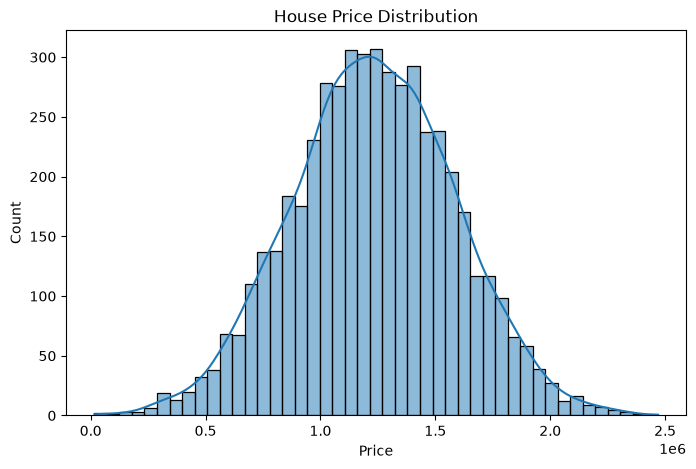

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], kde=True)

plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("Count")

plt.show()

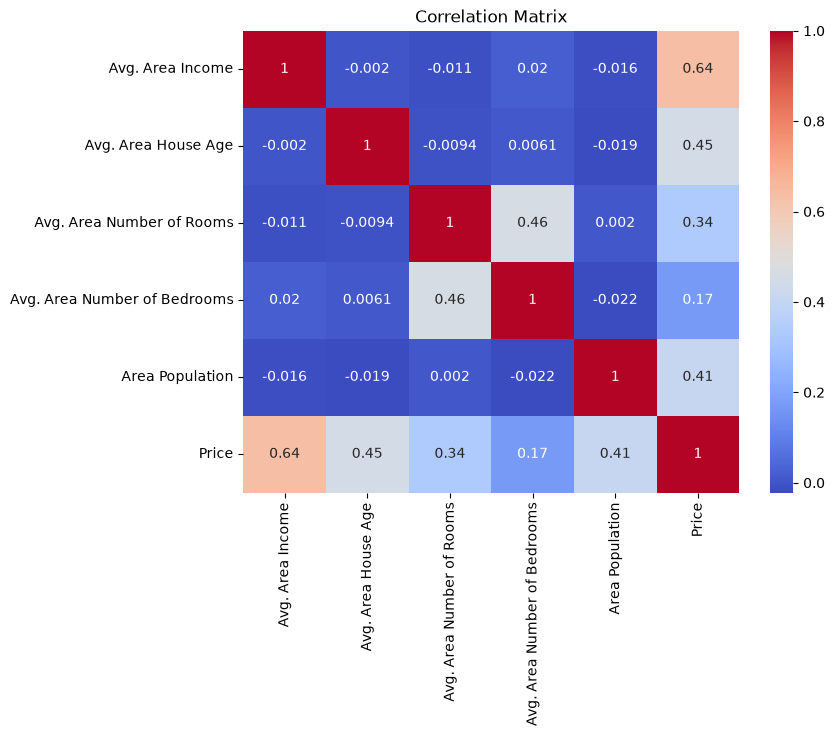

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(df.drop("Address", axis=1).corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

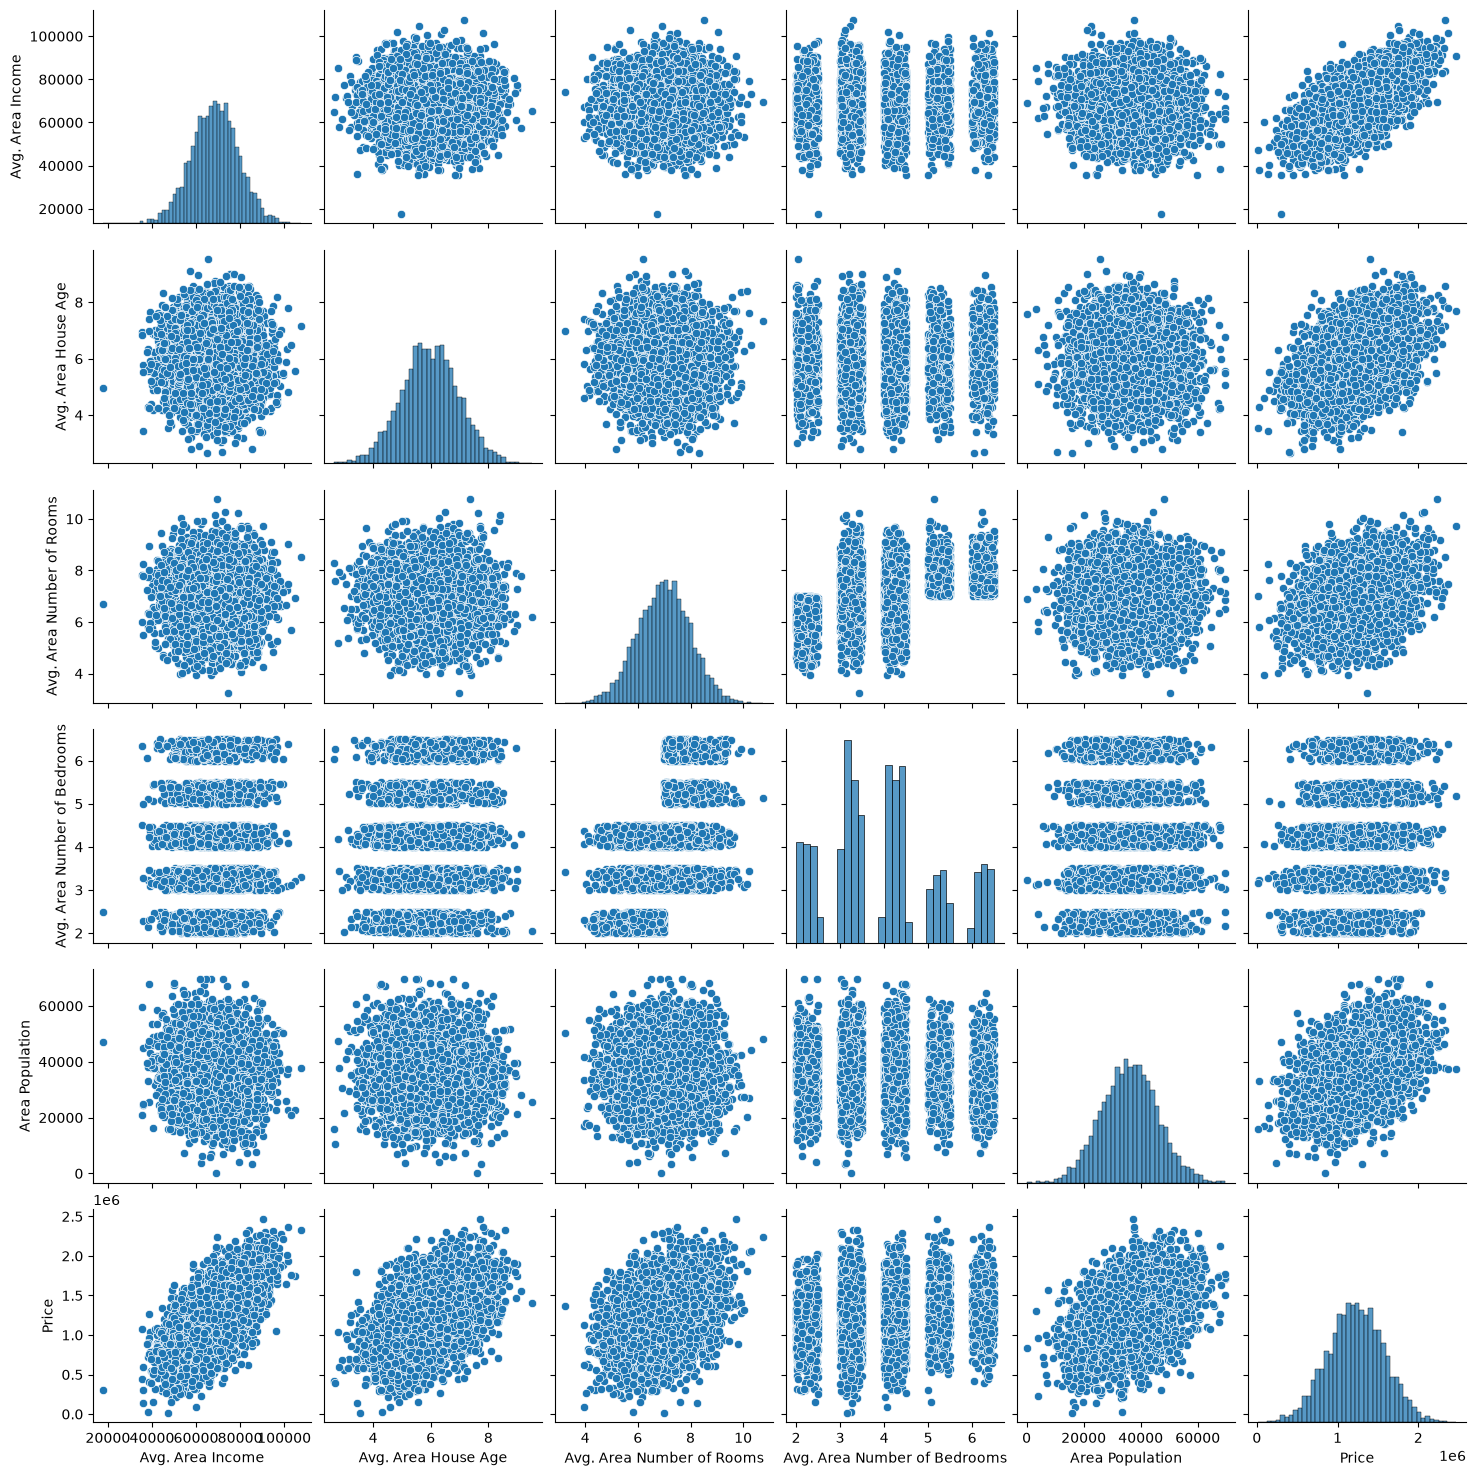

In [8]:
sns.pairplot(df.drop("Address", axis=1))

plt.show()

Observations:

• House prices are approximately normally distributed.
• Avg. Area Income has the strongest positive relationship with Price.
• Area Population, House Age, and Number of Rooms also positively influence house prices.
• Number of Bedrooms has the weakest relationship with Price.
• No major outliers are observed.
• The dataset is clean and suitable for Linear Regression.

## 5. Data Preprocessing

Here, we prepare the data for machine learning by selecting features and splitting the dataset.

In [17]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop(["Price", "Address"], axis=1)

# Target
y = df["Price"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 5)
(1000, 5)


## 6. Model Training

In this step, we train a Linear Regression model using the training dataset.
Linear Regression learns the relationship between the input features and the house price.

In [18]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop(["Price", "Address"], axis=1)

# Target
y = df["Price"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(4000, 5)
(1000, 5)


In [19]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 7. Model Evaluation

In this step, we evaluate the performance of the trained Linear Regression model by comparing the predicted house prices with the actual prices.

We use three evaluation metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

We also calculate the R² Score, which tells us how well the model explains the data.


In [20]:
 # Predict on Test Data

predictions = model.predict(X_test)

predictions[:5]

array([1308587.92718453, 1237037.22950269, 1243429.34023036,
       1228900.21368759, 1063320.907316  ])

In [21]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
1501,1339096.077,1.308588e+06
2586,1251794.179,1.237037e+06
2653,1340094.966,1.243429e+06
1055,1431507.623,1.228900e+06
705,1042373.524,1.063321e+06
106,1555320.500,1.544058e+06
589,1250882.292,1.094775e+06
2468,1039380.722,8.332847e+05
2413,832475.189,7.884129e+05
1600,1420648.281,1.469715e+06


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, predictions))

print("MSE :", mean_squared_error(y_test, predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, predictions)))

print("R2 Score :", r2_score(y_test, predictions))

MAE : 80879.09722218299
MSE : 10089009299.499416
RMSE : 100444.06054864278
R2 Score : 0.917997170698532


### Conclusion

The Linear Regression model performed very well on the housing dataset.

- Mean Absolute Error (MAE): 80,879
- Root Mean Squared Error (RMSE): 100,444
- R² Score: 0.918

The high R² score indicates that the model can explain about 91.8% of the variation in house prices, making it a strong predictive model.

## 8. Prediction

In [24]:
# ## 8. Prediction

# Example House Details
new_house = pd.DataFrame({
    "Avg. Area Income": [65000],
    "Avg. Area House Age": [5.5],
    "Avg. Area Number of Rooms": [7],
    "Avg. Area Number of Bedrooms": [4],
    "Area Population": [30000]
})

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 983225.1166435597


In [25]:
import pickle

# Save the trained model
with open("../model/house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
